In [5]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import math as m

from insolation import insolf

import pygrib
from netCDF4 import Dataset

In [6]:
from osgeo import gdal, osr

In [7]:
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

In [8]:
with Dataset(ERW_TOPO_FILE) as dem:
    d = dem['dem'][:].astype(np.float64)

d

masked_array(
  data=[[3576.69824219, 3589.36132812, 3599.52539062, ..., 3706.17773438,
         3714.56542969, 3718.16113281],
        [3606.23144531, 3619.91015625, 3635.71386719, ..., 3697.91894531,
         3706.26855469, 3710.46484375],
        [3642.26367188, 3665.57714844, 3695.79101562, ..., 3686.65136719,
         3695.55859375, 3700.64746094],
        ...,
        [3075.33984375, 3055.16503906, 3040.07226562, ..., 2723.90234375,
         2744.72949219, 2759.08886719],
        [3071.48632812, 3058.81152344, 3056.81640625, ..., 2713.35546875,
         2733.05371094, 2745.63085938],
        [3092.04492188, 3089.34179688, 3094.33105469, ..., 2700.45703125,
         2712.83105469, 2728.81835938]],
  mask=False,
  fill_value=1e+20)

In [9]:
with Dataset(ERW_TOPO_FILE) as dem:
    vf = dem['sky_view_factor'][:].astype(np.float64)

vf

masked_array(
  data=[[0.90764373, 0.90160327, 0.87204783, ..., 0.96763542, 0.97887733,
         0.98330146],
        [0.87995018, 0.86740591, 0.81930077, ..., 0.97601105, 0.98206188,
         0.98354592],
        [0.83752437, 0.8177492 , 0.77636379, ..., 0.97050725, 0.97584268,
         0.97335441],
        ...,
        [0.87855814, 0.89022444, 0.8855338 , ..., 0.95064361, 0.95388958,
         0.93882772],
        [0.90449759, 0.86569677, 0.84933238, ..., 0.95202325, 0.94747276,
         0.92465977],
        [0.890127  , 0.82381173, 0.78123565, ..., 0.9661788 , 0.94509181,
         0.91614504]],
  mask=False,
  fill_value=1e+20)

In [10]:
dataset = Dataset(ERW_TOPO_FILE)
# Get a list of variable names
variable_names = list(dataset.variables.keys())

# Print the variable names
print("Variables in the netCDF file:")
for name in variable_names:
    print(f"- {name}")

Variables in the netCDF file:
- y
- x
- dem
- mask
- veg_type
- veg_height
- veg_k
- veg_tau
- Alec2 mask
- projection
- sky_view_factor
- terrain_config_factor
- slope


In [11]:
with Dataset(ERW_TOPO_FILE) as dem:
    print(dem['projection'])

<class 'netCDF4._netCDF4.Variable'>
|S1 projection()
    grid_mapping_name: universal_transverse_mercator
    utm_zone_number: 13.0
    semi_major_axis: 6378137.0
    inverse_flattening: 298.257223563
    spatial_ref: PROJCS["WGS84/UTMzone13N",
GEOGCS["WGS84",
DATUM["WGS_1984",
SPHEROID["WGS84",6378137,298.257223563,
AUTHORITY["EPSG","7030"]],
AUTHORITY["EPSG","6326"]],
PRIMEM["Greenwich",0,
AUTHORITY["EPSG","8901"]],
UNIT["degree",0.01745329251994328,
AUTHORITY["EPSG","9122"]],
AUTHORITY["EPSG","4326"]],
UNIT["metre",1,
AUTHORITY["EPSG","9001"]],
PROJECTION["Transverse_Mercator"],
PARAMETER["latitude_of_origin",0],
PARAMETER["central_meridian",-105],
PARAMETER["scale_factor",0.9996],
PARAMETER["false_easting",500000],
PARAMETER["false_northing",0],
AUTHORITY["EPSG","32613"],
AXIS["Easting",EAST],
AXIS["Northing",NORTH]]
    _CoordinateTransformType: Projection
    _CoordinateAxisTypes: GeoX GeoY
unlimited dimensions: 
current shape = ()
filling on, default _FillValue of   used


In [12]:
with Dataset(ERW_TOPO_FILE) as dem:
    latitude_var = dem['y'][:].astype(np.float64)
    longitude_var = dem['x'][:].astype(np.float64)
    # latitude_data = latitude_var[:]
    # longitude_data = longitude_var[:]
    # nc_file.close()

# print(latitude_data)
# UTM Coords

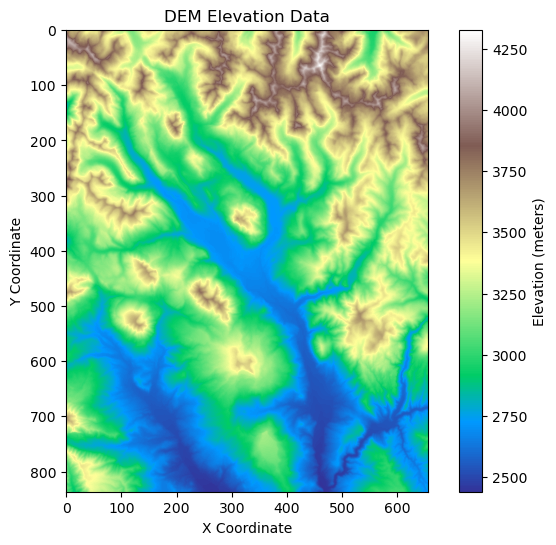

In [13]:
plt.figure(figsize=(8, 6))
plt.imshow(d, cmap='terrain', origin='upper')  # Use 'terrain' colormap for elevation
plt.colorbar(label='Elevation (meters)')  # Add color bar with a label
plt.title("DEM Elevation Data")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

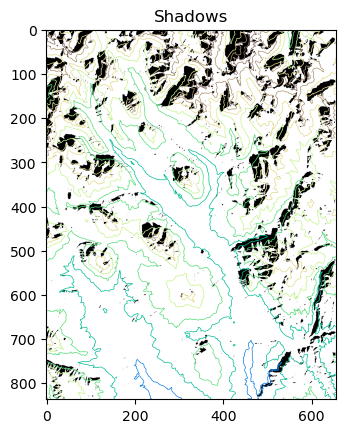

In [14]:
sv = insolf.normalvector(80,140)
# calculate and plot shadows 
sh = insolf.doshade(np.array(d), 100, sv)
plt.imshow(sh, cmap='Greys_r')
# plt.colorbar()
plt.contour(d, cmap = 'terrain', linewidths=0.5)
plt.title('Shadows')
plt.show()

## Insolation

[ 61.87014747  71.68129236  82.53405618  93.95928713 105.60927828
 117.16150608 128.20900038 138.08282214 145.55439355 148.72465406
 146.31565984 139.32838111 129.6980707  118.75762811 107.2342751
  95.55778389  84.05337738  73.05688428  63.0110764   54.56846969
  48.65571829  46.30079936  48.04524702] [231.14259573 243.32050112 253.75997797 263.29069349 272.67955438
 282.75570422 294.62424692 309.94995164 330.90484384 357.88275191
  25.41293102  47.30375942  63.29304363  75.52746389  85.76874341
  95.1836636  104.62546478 114.86142209 126.71435126 141.0703563
 158.53264422 178.51283807 198.70762898]


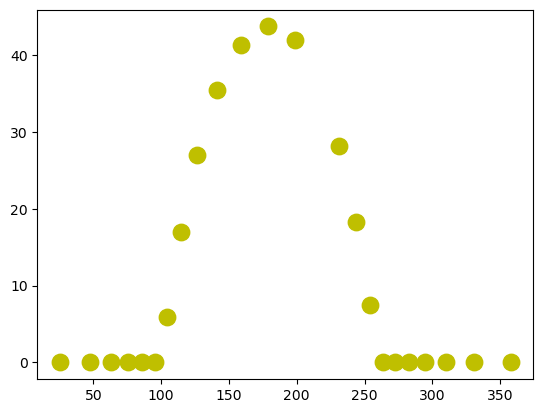

In [15]:
# Julian Day hourly intervals 
jdrng = insolf.julian_day(2023,3,1,np.arange(1, 24))


# sun path over the day at sprint equinox in the Pyrenees
latitude = 38.8697
longitude = 106.9878
tmz = -7
azimuth, zenith = insolf.sunpos(insolf.sunvector(jdrng,latitude,longitude,tmz))
print(zenith, azimuth)
elevation = 90-zenith
elevation[elevation < 0] = 0
plt.scatter(azimuth,elevation, s=140, facecolors='y', edgecolors='y')
plt.show()

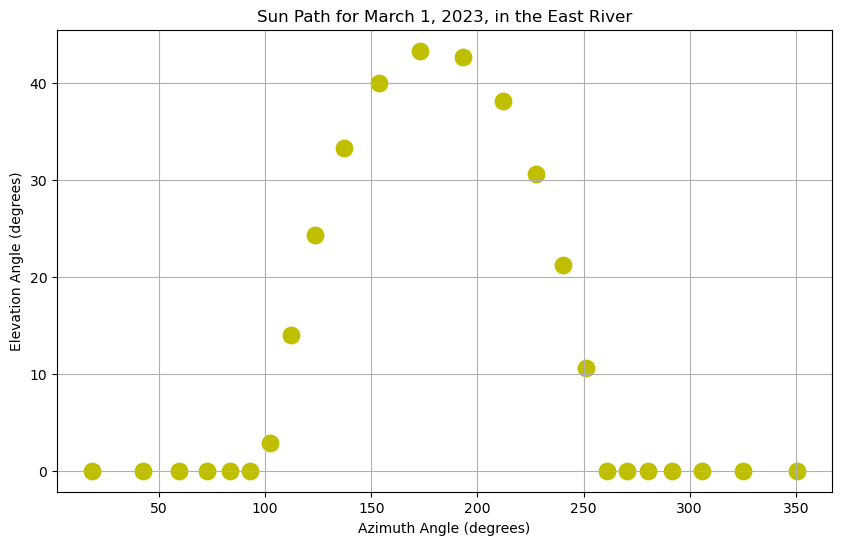

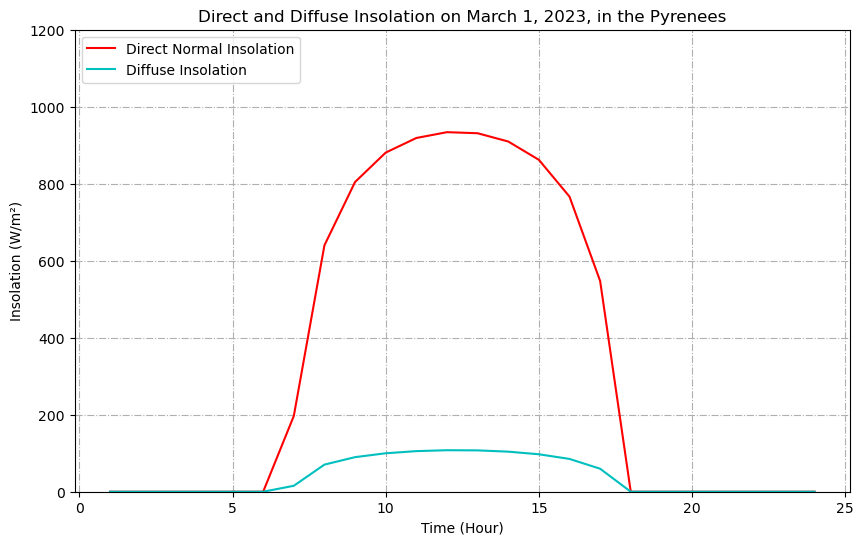

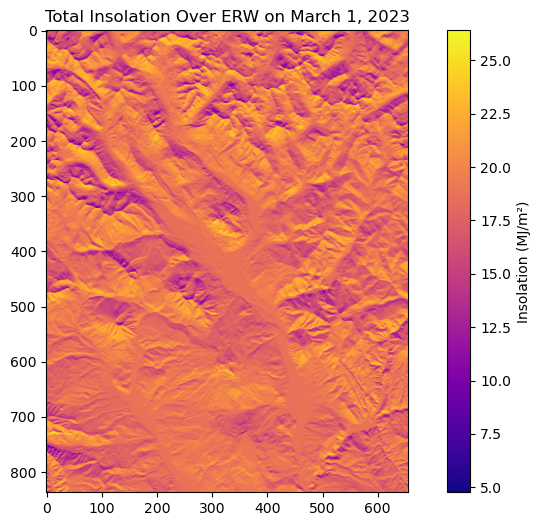

In [16]:


# Step 1: Define parameters
latitude = 38.8697  # ERW latitude
longitude = -106.9878  # ERW longitude
timezone = -7  # Timezone for ERW

# For simplicity, let's assume values for height, visibility, RH, tempK, O3, and alphag:
height = 2000  # Altitude in meters
visibility = 60  # Visibility in km
RH = 55  # Relative Humidity in percentage
tempK = 285.0  # Air temperature in Kelvin
O3 = 0.02  # Ozone thickness in meters
alphag = 0.2  # Albedo of surrounding terrain

# Step 2: Generate Julian Day for March 1, 2023 (1 to 24 hours)
jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

# Step 3: Calculate Sun Position (Azimuth and Zenith) over the day
sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
azimuth, zenith = insolf.sunpos(sunv)

# Step 4: Calculate Solar Elevation Angle (90 - Zenith) and set negative values to zero
elevation = 90 - zenith
elevation[elevation < 0] = 0  # Sun below the horizon

# Step 5: Plot Sun Path (Azimuth vs. Elevation)
plt.figure(figsize=(10, 6))
plt.scatter(azimuth, elevation, s=140, facecolors='y', edgecolors='y')
plt.title("Sun Path for March 1, 2023, in the East River")
plt.xlabel("Azimuth Angle (degrees)")
plt.ylabel("Elevation Angle (degrees)")
plt.grid(True)
plt.show()

# Step 6: Calculate Insolation for Each Hour (Direct and Diffuse)
Idir = np.zeros(24)
Idiff = np.zeros(24)

for i in range(24):
    # Insolation at each hour using Zenith, Julian Day, and other parameters
    Idir[i], Idiff[i] = insolf.insolation(zenith[i], jdrng[i], height, visibility, RH, tempK, O3, alphag)

# Step 7: Plot the Insolation (Direct Normal, Diffuse) over the Day
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 25), Idir, 'r', label='Direct Normal Insolation')
plt.plot(np.arange(1, 25), Idiff, 'c', label='Diffuse Insolation')
plt.legend(loc="upper left")
plt.grid(visible=True, linestyle="-.")
plt.xlabel('Time (Hour)')
plt.ylabel('Insolation (W/m²)')
plt.title("Direct and Diffuse Insolation on March 1, 2023, in the Pyrenees")
plt.ylim(0, 1200)  # Set y-axis limit to visualize better
plt.show()

# Step 8: Calculate Insolation over a DEM Grid (e.g., Pyrenees)
# For simplicity, load a DEM file (for example, a Pyrenees DEM)
# demP = rasterio.open('https://meteoexploration.com/insol/data/dempyrenees.tif')  # Example DEM URL
# dlxy = demP.res[0]  # Resolution of DEM
# dem = demP.read(1)  # Read the DEM data
dem = d
dlxy = 100

# Initialize total insolation array (same shape as DEM grid)
I_tot = np.zeros(dem.shape)

# Calculate Insolation over the DEM Grid for Each Hour
for i in np.arange(24):
    # Solar vector for each hour
    sunv = insolf.sunvector(jdrng[i], latitude, longitude, timezone)
    # Hillshading based on solar position
    hsh = insolf.hillshading(dem, dlxy, sunv)
    # Calculate insolation for each hour
    Idir_hour, Idiff_hour = insolf.insolation(zenith[i], jdrng[i], height, visibility, RH, tempK, O3, alphag)
    # Convert from W/m² to MJ/m² (for a 1-hour period)
    W2MJ = 3600e-6  # Watts/m² to MJ/m² hourly computation
    I_tot += W2MJ * Idir_hour * hsh + W2MJ * Idiff_hour  # Accumulate total insolation

# Step 9: Plot Total Insolation over the DEM Grid (Pyrenees)
plt.figure(figsize=(10, 6))
plt.imshow(I_tot, cmap='plasma')
plt.colorbar(label="Insolation (MJ/m²)")
plt.title("Total Insolation Over ERW on March 1, 2023")
plt.show()


In [17]:
jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

# Step 3: Calculate Sun Position (Azimuth and Zenith) over the day
sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
azimuth, zenith = insolf.sunpos(sunv)

# Step 4: Calculate Solar Elevation Angle (90 - Zenith) and set negative values to zero
elevation = 90 - zenith
elevation[elevation < 0] = 0  # Sun below the horizon

# Step 5: Calculate Normal Vectors for Shadow Calculation (shading)
sv = insolf.normalvector(zenith, azimuth)
sv.shape

(3, 24)

In [18]:
d.mean()

3115.9901459160865

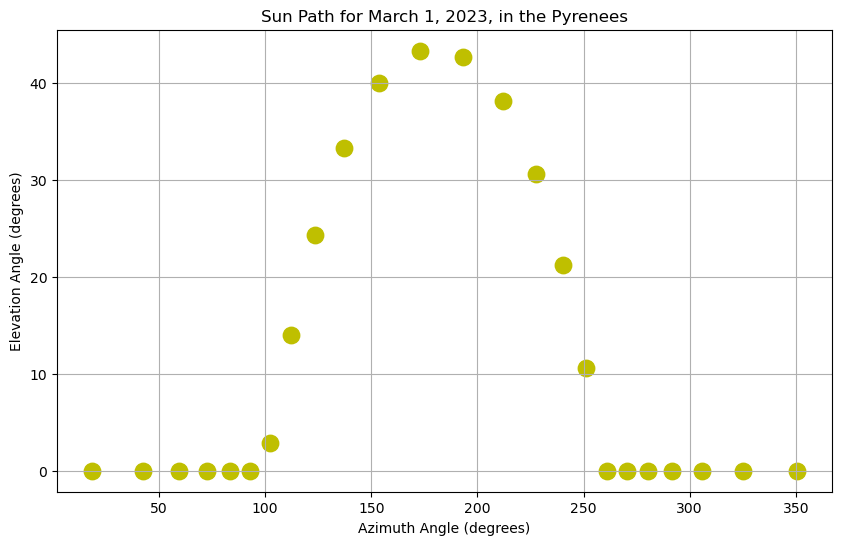

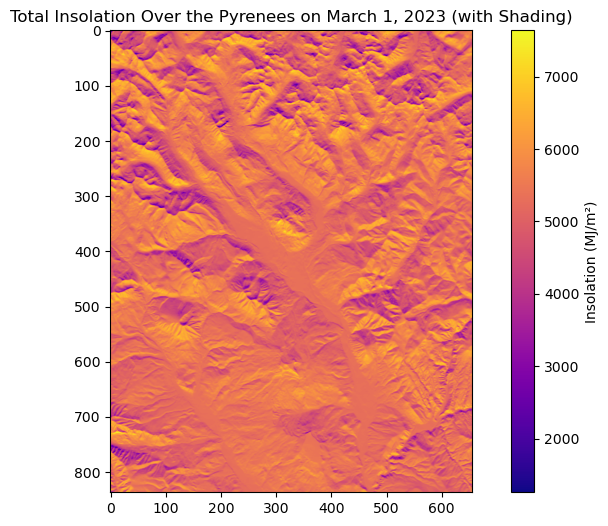

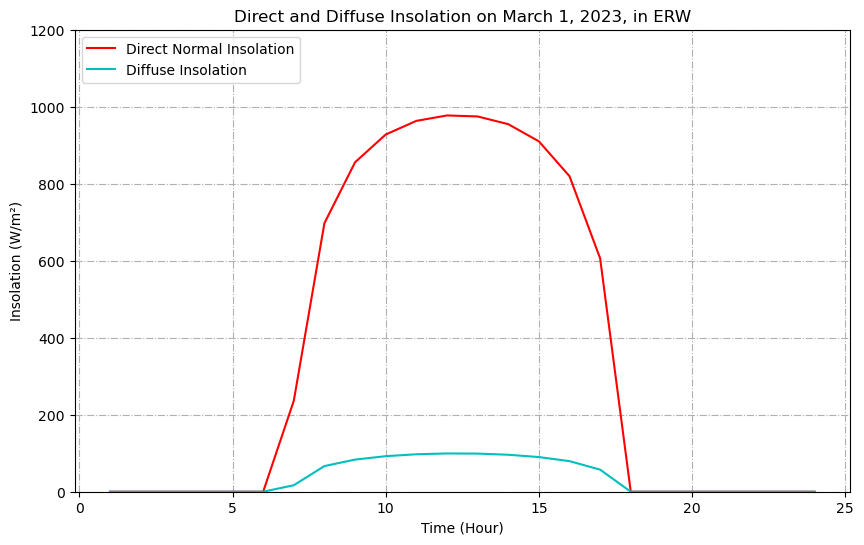

In [19]:

# Step 1: Define parameters
latitude = 38.8697  # Pyrenees latitude
longitude = -106.9878  # Pyrenees longitude
timezone = -7  # Timezone for Pyrenees

# For simplicity, let's assume values for height, visibility, RH, tempK, O3, and alphag:
height = d.mean()  # Altitude in meters
visibility = 60  # Visibility in km
RH = 55  # Relative Humidity in percentage
tempK = 275.0  # Air temperature in Kelvin
O3 = 0.02  # Ozone thickness in meters
alphag = 0.2  # Albedo of surrounding terrain

# Step 2: Generate Julian Day for March 1, 2023 (1 to 24 hours)
jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

# Step 3: Calculate Sun Position (Azimuth and Zenith) over the day
sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
azimuth, zenith = insolf.sunpos(sunv)

# Step 4: Calculate Solar Elevation Angle (90 - Zenith) and set negative values to zero
elevation = 90 - zenith
elevation[elevation < 0] = 0  # Sun below the horizon

# Step 5: Calculate Normal Vectors for Shadow Calculation (shading)
sv = insolf.normalvector(zenith, azimuth)  # Normal vector for each hour's sun position

# Step 6: Load DEM Grid (ERW DEM example)
dem = d
dlxy = 100

# Initialize arrays for storing hourly Idir and Idiff values
Idir_all = np.zeros(24)  # Direct Insolation for each hour
Idiff_all = np.zeros(24)  # Diffuse Insolation for each hour

# Initialize total insolation array (same shape as DEM grid)
I_tot = np.zeros(dem.shape)

# Step 7: Loop over each hour to calculate Insolation, Shading, and Store Results
for i in np.arange(24):
    # Solar vector for each hour
    sunv = insolf.sunvector(jdrng[i], latitude, longitude, timezone)
    # Hillshading based on solar position
    hsh = insolf.hillshading(dem, dlxy, sunv)
    
    # Calculate Insolation (Direct and Diffuse) for each hour
    Idir_hour0, Idiff_hour0 = insolf.insolation(zenith[i], jdrng[i], height, visibility, RH, tempK, O3, alphag)
    
    # Store the hourly insolation values into arrays
    Idir_all[i] = Idir_hour0
    Idiff_all[i] = Idiff_hour0

    # Calculate shading effect using the normal vector (sv[:, i]) and DEM data
    sh = insolf.doshade(np.array(dem), 100, sv[:, i])  # Correcting the shading function with sv[:, i]

    # Calculate Insolation (Direct and Diffuse) for each hour
    Idir_hour, Idiff_hour = insolf.insolation(zenith[i], jdrng[i], d, visibility, RH, tempK, O3, alphag)
    
    # Save arrays for each Idir_hour and Idiff_hour - as all ndarray
    
    # Multiply the shading effect by the direct insolation (Idir_hour)
    I_tot += (Idir_hour * sh * hsh) + (Idiff_hour)  # Diffuse insolation is not shaded

# Step 8: Plot Sun Path (Azimuth vs. Elevation)
plt.figure(figsize=(10, 6))
plt.scatter(azimuth, elevation, s=140, facecolors='y', edgecolors='y')
plt.title("Sun Path for March 1, 2023, in the Pyrenees")
plt.xlabel("Azimuth Angle (degrees)")
plt.ylabel("Elevation Angle (degrees)")
plt.grid(True)
plt.show()

# Step 9: Plot the Total Insolation (with Shading) Over the DEM Grid
plt.figure(figsize=(10, 6))
plt.imshow(I_tot, cmap='plasma')
plt.colorbar(label="Insolation (MJ/m²)")
plt.title("Total Insolation Over the Pyrenees on March 1, 2023 (with Shading)")
plt.show()

# Step 10: Plot Insolation (Direct Normal and Diffuse) Over the Day
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 25), Idir_all, 'r', label='Direct Normal Insolation')
plt.plot(np.arange(1, 25), Idiff_all, 'c', label='Diffuse Insolation')
plt.legend(loc="upper left")
plt.grid(visible=True, linestyle="-.")
plt.xlabel('Time (Hour)')
plt.ylabel('Insolation (W/m²)')
plt.title("Direct and Diffuse Insolation on March 1, 2023, in ERW")
plt.ylim(0, 1200)  # Set y-axis limit to visualize better
plt.show()


0of24
1of24
2of24
3of24
4of24
5of24
6of24
7of24
8of24
9of24
10of24
11of24
12of24
13of24
14of24
15of24
16of24
17of24
18of24
19of24
20of24
21of24
22of24
23of24


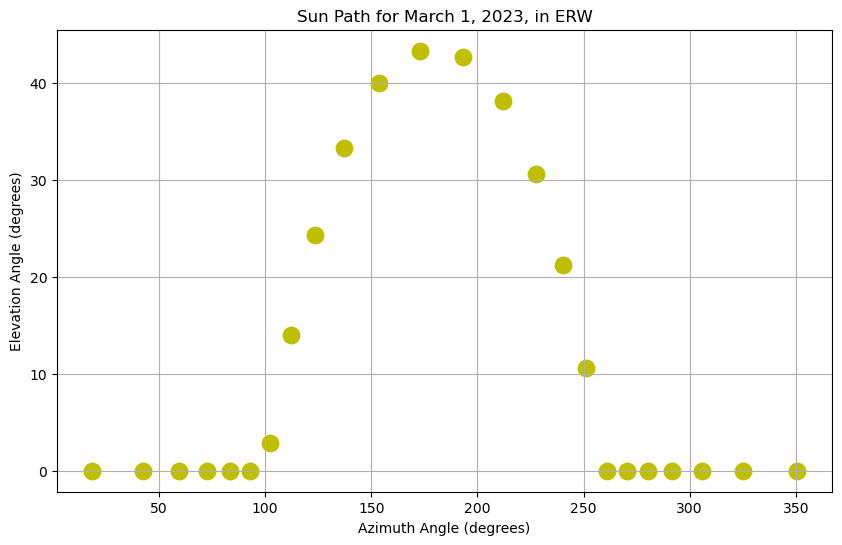

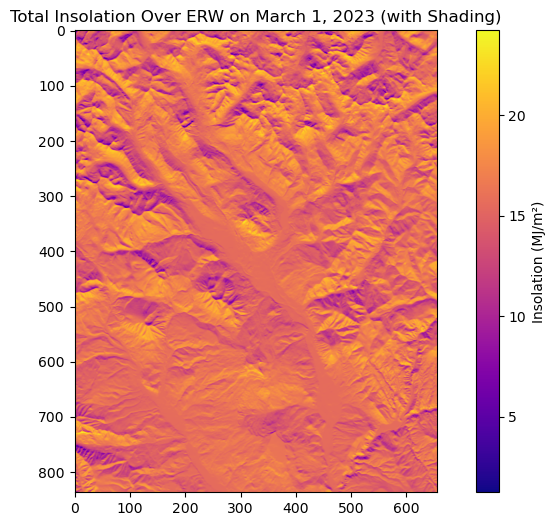

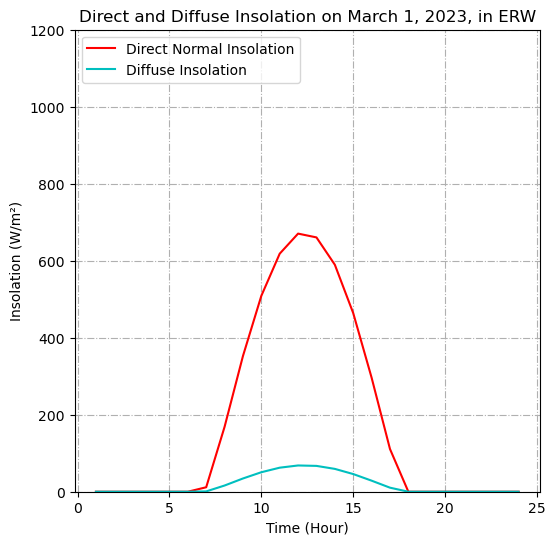

In [20]:


# Step 1: Define parameters
latitude = 38.8697  # ERW latitude (example, replace with actual)
longitude = -106.9878  # ERW longitude (example, replace with actual)
timezone = -7  # Timezone for ERW

# For simplicity, let's assume values for height, visibility, RH, tempK, O3, and alphag:
height = d.mean()  # Altitude in meters (using DEM mean)
visibility = 60  # Visibility in km
RH = 55  # Relative Humidity in percentage
tempK = 275.0  # Air temperature in Kelvin
O3 = 0.02  # Ozone thickness in meters
alphag = 0.2  # Albedo of surrounding terrain

# Step 2: Generate Julian Day for March 1, 2023 (1 to 24 hours)
jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

# Step 3: Calculate Sun Position (Azimuth and Zenith) over the day
sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
azimuth, zenith = insolf.sunpos(sunv)

# Step 4: Calculate Solar Elevation Angle (90 - Zenith) and set negative values to zero
elevation = 90 - zenith
elevation[elevation < 0] = 0  # Sun below the horizon

# Step 5: Calculate Normal Vectors for Shadow Calculation (shading)
sv = insolf.normalvector(zenith, azimuth)  # Normal vector for each hour's sun position

# Step 6: Load DEM Grid (ERW DEM example)
dem = d  # Use your DEM array `d`
dlxy = 100  # Grid resolution in meters

# Initialize arrays for storing hourly Idir and Idiff values
Idir_all = np.zeros(24)  # Direct Insolation for each hour
Idiff_all = np.zeros(24)  # Diffuse Insolation for each hour

# Initialize total insolation array (same shape as DEM grid)
I_tot = np.zeros(dem.shape)

# Step 7: Loop over each hour to calculate Insolation, Shading, and Store Results
for i in np.arange(24):
    print(str(i) + "of" + str(len(jdrng)) )
    # Solar vector for each hour
    sunv = insolf.sunvector(jdrng[i], latitude, longitude, timezone)
    
    # Hillshading based on solar position
    hsh = insolf.hillshading(dem, dlxy, sunv)  # Hillshading function based on DEM data
    
    # Calculate Insolation (Direct and Diffuse) for each hour
    Idir_hour0, Idiff_hour0 = insolf.insolation(zenith[i], jdrng[i], height, visibility, RH, tempK, O3, alphag)
    
    # Store the hourly insolation values into arrays
    Idir_all[i] = Idir_hour0 * m.cos(zenith[i]*m.pi/180)
    Idiff_all[i] = Idiff_hour0 * m.cos(zenith[i]*m.pi/180)

    # Calculate shading effect using the normal vector (sv[:, i]) and DEM data
    sh = insolf.doshade(np.array(dem), 100, sv[:, i])  # Shading calculation with DEM and solar vector

    # Compute hourly Insolation using shading
    Idir_hour, Idiff_hour = insolf.insolation(zenith[i], jdrng[i], d, visibility, RH, tempK, O3, alphag)
    
    # Convert to MJ/m² (W/m² to MJ/m² for hourly insolation)
    W2MJ = 3600e-6  # Conversion factor from W/m² to MJ/m²
    
    # Multiply the shading effect by the direct insolation (Idir_hour)
    I_tot += (Idir_hour * sh * hsh * W2MJ) + (Idiff_hour * m.cos(zenith[i]) * W2MJ)  # Diffuse insolation is not shaded

    # Save the results for each hour
    # For future analysis, you may save Idir_all, Idiff_all into separate arrays for other use
    # These arrays are already populated in the above loop

# Step 8: Plot Sun Path (Azimuth vs. Elevation)
plt.figure(figsize=(10, 6))
plt.scatter(azimuth, elevation, s=140, facecolors='y', edgecolors='y')
plt.title("Sun Path for March 1, 2023, in ERW")
plt.xlabel("Azimuth Angle (degrees)")
plt.ylabel("Elevation Angle (degrees)")
plt.grid(True)
plt.show()

# Step 9: Plot the Total Insolation (with Shading) Over the DEM Grid
plt.figure(figsize=(10, 6))
plt.imshow(I_tot, cmap='plasma')
plt.colorbar(label="Insolation (MJ/m²)")
plt.title("Total Insolation Over ERW on March 1, 2023 (with Shading)")
plt.show()

# Step 10: Plot Insolation (Direct Normal and Diffuse) Over the Day
plt.figure(figsize=(6, 6))
plt.plot(np.arange(1, 25), Idir_all, 'r', label='Direct Normal Insolation')
plt.plot(np.arange(1, 25), Idiff_all, 'c', label='Diffuse Insolation')
plt.legend(loc="upper left")
plt.grid(visible=True, linestyle="-.")
plt.xlabel('Time (Hour)')
plt.ylabel('Insolation (W/m²)')
plt.title("Direct and Diffuse Insolation on March 1, 2023, in ERW")
plt.ylim(0, 1200)  # Set y-axis limit to visualize better
plt.show()


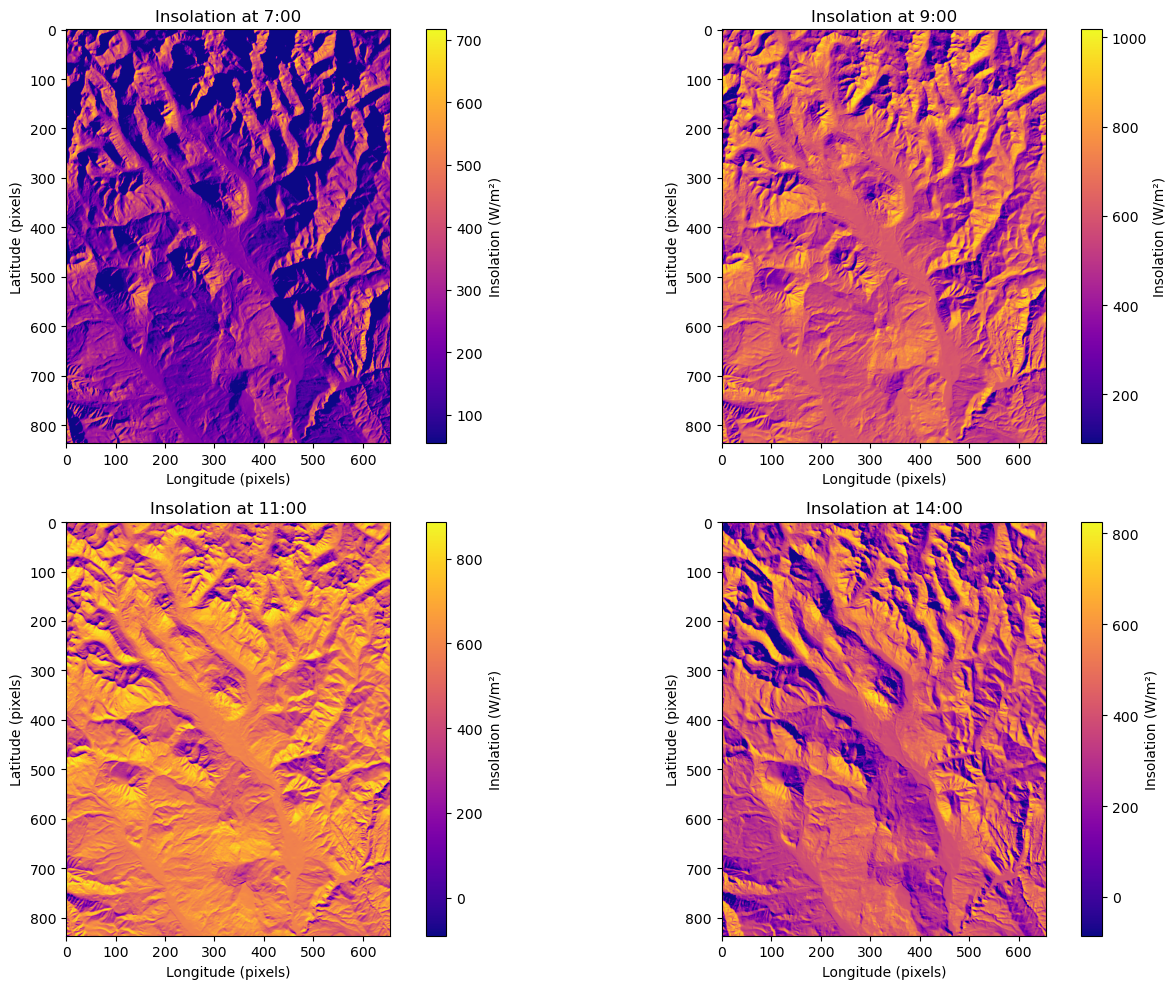

In [21]:


# Assuming the DEM grid is stored in `d` and has already been loaded
dem = d  # Replace `d` with your DEM array
dlxy = 50  # Grid resolution in meters (for DEM)

# Assuming a fixed set of parameters for this example
latitude = 38.8697  # ERW latitude (example, replace with actual)
longitude = -106.9878  # ERW longitude (example, replace with actual)
timezone = -7  # Timezone for ERW

# Parameters for insolation calculation
height = dem.mean()  # Altitude in meters (using DEM mean)
visibility = 60  # Visibility in km
RH = 55  # Relative Humidity in percentage
tempK = 275.0  # Air temperature in Kelvin
O3 = 0.02  # Ozone thickness in meters
alphag = 0.2  # Albedo of surrounding terrain

# Step 1: Generate Julian Day for March 1, 2023 (1 to 24 hours)
jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

# Step 2: Calculate Sun Position (Azimuth and Zenith) over the day
sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
azimuth, zenith = insolf.sunpos(sunv)

# Calculate normal vectors for shading (sv)
sv = insolf.normalvector(zenith, azimuth)

# Initialize a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hour indices for plotting (7 AM, 9 AM, 11 AM, 2 PM)
hours = [7, 9, 11, 14]
I_tot = {}

# Step 4: Loop through the selected hours and calculate the total insolation with shading
for i, hour in enumerate(hours):
    # Calculate shading effect using the normal vector (sv[:, hour]) and DEM data
    sh = insolf.doshade(np.array(dem), dlxy, sv[:, hour])  # Use sv[:, hour] for correct index
    
    # Calculate the insolation for this hour
    Idir_hour, Idiff_hour = insolf.insolation(zenith[hour], jdrng[hour], height, visibility, RH, tempK, O3, alphag)
    
    # Apply hill shading (assuming hill shading is applied correctly)
    hsh = insolf.hillshading(dem, dlxy, sunv[:, hour])  # Correct access to sunv for each hour
    
    # Compute total insolation with shading
    I_tot[hour] = (Idir_hour * sh * hsh) + (Idiff_hour * m.cos(zenith[hour]))  # Diffuse insolation is not shaded

    # Plot the result for this hour in the appropriate subplot
    ax = axes[i // 2, i % 2]  # Determine subplot position
    cax = ax.imshow(I_tot[hour], cmap='plasma')  # Plot the insolation with shading
    ax.set_title(f"Insolation at {hour}:00")
    ax.set_xlabel('Longitude (pixels)')
    ax.set_ylabel('Latitude (pixels)')
    fig.colorbar(cax, ax=ax, label="Insolation (W/m²)")

# Step 5: Adjust layout and show plot
plt.tight_layout()
plt.show()


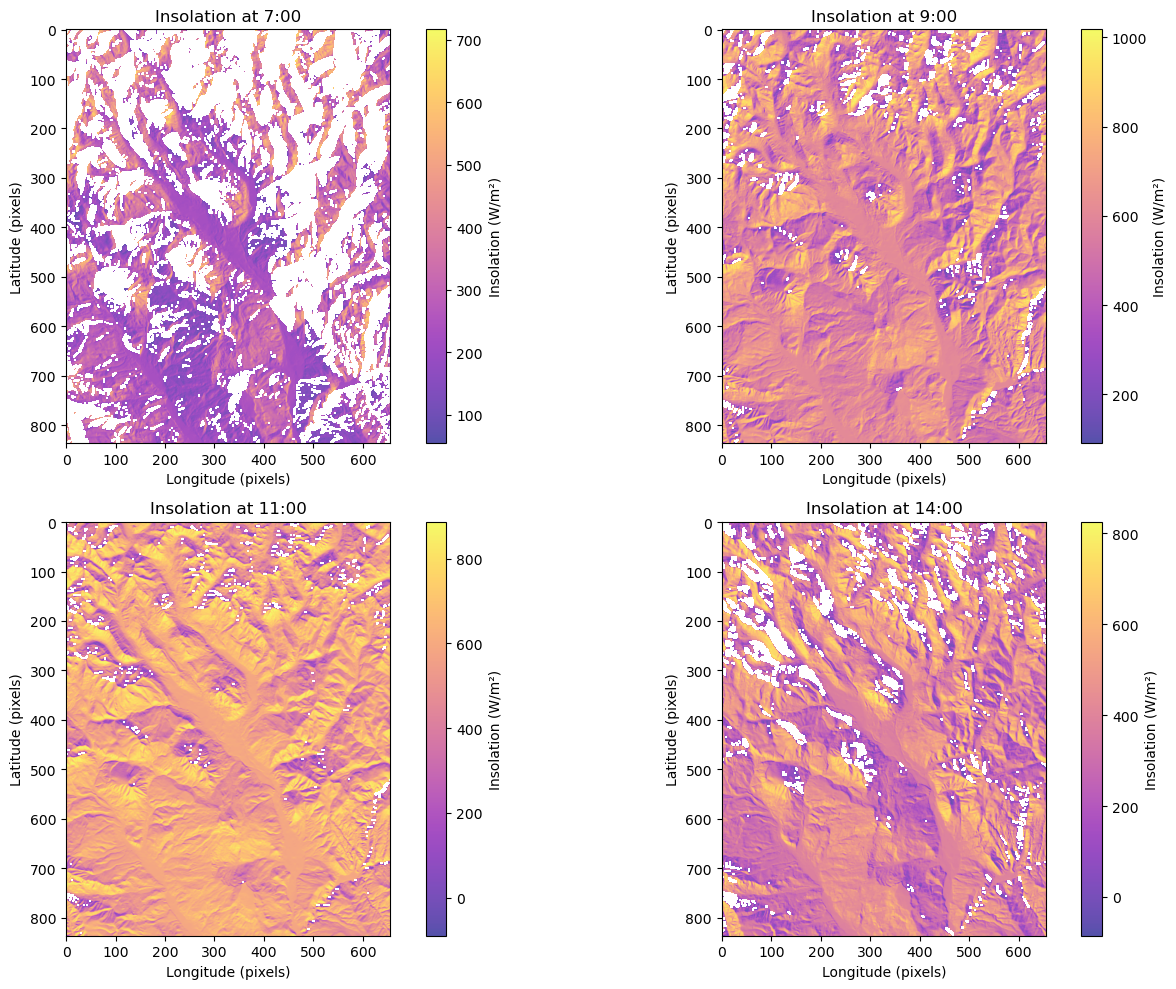

In [22]:


# Assuming the DEM grid is stored in `d` and has already been loaded
dem = d  # Replace `d` with your DEM array
dlxy = 50  # Grid resolution in meters (for DEM)

# Assuming a fixed set of parameters for this example
latitude = 38.8697  # ERW latitude (example, replace with actual)
longitude = -106.9878  # ERW longitude (example, replace with actual)
timezone = -7  # Timezone for ERW

# Parameters for insolation calculation
height = dem.mean()  # Altitude in meters (using DEM mean)
visibility = 60  # Visibility in km
RH = 55  # Relative Humidity in percentage
tempK = 275.0  # Air temperature in Kelvin
O3 = 0.02  # Ozone thickness in meters
alphag = 0.2  # Albedo of surrounding terrain

# Step 1: Generate Julian Day for March 1, 2023 (1 to 24 hours)
jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

# Step 2: Calculate Sun Position (Azimuth and Zenith) over the day
sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
azimuth, zenith = insolf.sunpos(sunv)

# Calculate normal vectors for shading (sv)
sv = insolf.normalvector(zenith, azimuth)

# Initialize a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hour indices for plotting (7 AM, 9 AM, 11 AM, 2 PM)
hours = [7, 9, 11, 14]
I_tot = {}

# Step 4: Loop through the selected hours and calculate the total insolation with shading
for i, hour in enumerate(hours):
    # Calculate shading effect using the normal vector (sv[:, hour]) and DEM data
    sh = insolf.doshade(np.array(dem), dlxy, sv[:, hour])  # Use sv[:, hour] for correct index
    
    # Mask shading (values of 0 as black, values of 1 as transparent)
    sh_masked = np.ma.masked_where(sh == 0, sh)  # Mask 0 values (no shading)

    # Calculate the insolation for this hour
    Idir_hour, Idiff_hour = insolf.insolation(zenith[hour], jdrng[hour], height, visibility, RH, tempK, O3, alphag)
    
    # Apply hill shading (assuming hill shading is applied correctly)
    hsh = insolf.hillshading(dem, dlxy, sunv[:, hour])  # Correct access to sunv for each hour
    
    # Compute total insolation with shading
    I_tot[hour] = (Idir_hour * sh_masked * hsh) + (Idiff_hour * m.cos(zenith[hour]))  # Diffuse insolation is not shaded

    # Plot the result for this hour in the appropriate subplot
    ax = axes[i // 2, i % 2]  # Determine subplot position
    cax = ax.imshow(I_tot[hour], cmap='plasma')  # Plot the insolation with shading
    
    # Add a mask for transparent shading
    cax.set_alpha(0.7)  # Set transparency level for the plot

    ax.set_title(f"Insolation at {hour}:00")
    ax.set_xlabel('Longitude (pixels)')
    ax.set_ylabel('Latitude (pixels)')
    fig.colorbar(cax, ax=ax, label="Insolation (W/m²)")

# Step 5: Adjust layout and show plot
plt.tight_layout()
plt.show()


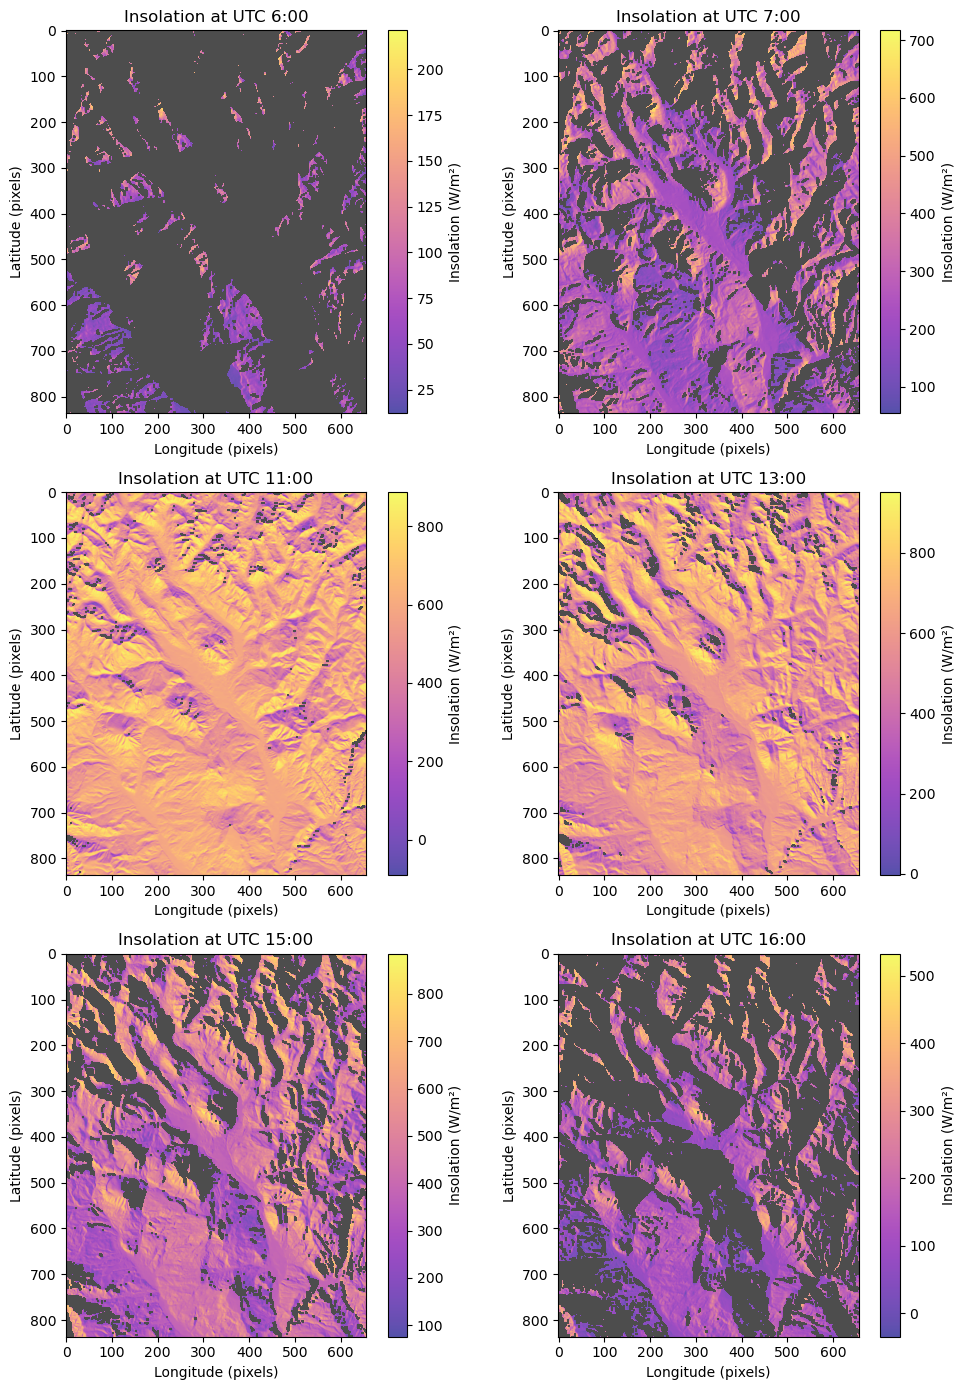

In [23]:


# Assuming the DEM grid is stored in `d` and has already been loaded
dem = d  # Replace `d` with your DEM array
dlxy = 50  # Grid resolution in meters (for DEM)

# Assuming a fixed set of parameters for this example
latitude = 38.8697  # ERW latitude (example, replace with actual)
longitude = -106.9878  # ERW longitude (example, replace with actual)
timezone = -7  # Timezone for ERW

# Parameters for insolation calculation
height = dem.mean()  # Altitude in meters (using DEM mean)
visibility = 60  # Visibility in km
RH = 55  # Relative Humidity in percentage
tempK = 275.0  # Air temperature in Kelvin
O3 = 0.02  # Ozone thickness in meters
alphag = 0.2  # Albedo of surrounding terrain

# Step 1: Generate Julian Day for March 1, 2023 (1 to 24 hours)
jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

# Step 2: Calculate Sun Position (Azimuth and Zenith) over the day
sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
azimuth, zenith = insolf.sunpos(sunv)

# Calculate normal vectors for shading (sv)
sv = insolf.normalvector(zenith, azimuth)

# Initialize a 2x2 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(10, 14))

# Hour indices for plotting (7 AM, 9 AM, 11 AM, 2 PM)
# hours = [7, 9, 11, 13, 15, 17]
hours = [6, 7, 11, 13, 15, 16]
I_tot = {}

# Step 4: Loop through the selected hours and calculate the total insolation with shading
for i, hour in enumerate(hours):
    # Calculate shading effect using the normal vector (sv[:, hour]) and DEM data
    sh = insolf.doshade(np.array(dem), dlxy, sv[:, hour])  # Use sv[:, hour] for correct index
    
    # Mask shading (values of 0 as black, values of 1 as transparent)
    sh_masked = np.ma.masked_where(sh == 0, sh)  # Mask 0 values (no shading)

    # Calculate the insolation for this hour
    Idir_hour, Idiff_hour = insolf.insolation(zenith[hour], jdrng[hour], height, visibility, RH, tempK, O3, alphag)
    
    # Apply hill shading (assuming hill shading is applied correctly)
    hsh = insolf.hillshading(dem, dlxy, sunv[:, hour])  # Correct access to sunv for each hour
    
    # Compute total insolation with shading
    I_tot[hour] = (Idir_hour * sh_masked * hsh) + (Idiff_hour * m.cos(zenith[hour]))  # Diffuse insolation is not shaded

    # Create a custom colormap that maps masked values to black
    cmap = plt.cm.plasma  # Use the plasma colormap
    cmap.set_bad(color='black')  # Set masked (bad) values to black

    # Plot the result for this hour in the appropriate subplot
    ax = axes[i // 2, i % 2]  # Determine subplot position
    cax = ax.imshow(I_tot[hour], cmap=cmap)  # Plot the insolation with shading
    
    # Add a mask for transparent shading
    cax.set_alpha(0.7)  # Set transparency level for the plot

    ax.set_title(f"Insolation at UTC {hour}:00")
    ax.set_xlabel('Longitude (pixels)')
    ax.set_ylabel('Latitude (pixels)')
    fig.colorbar(cax, ax=ax, label="Insolation (W/m²)")

# Step 5: Adjust layout and show plot
plt.tight_layout()
plt.show()


In [24]:
import pygrib

# Open the GRIB file
hrrr_file = f"{HRRR_DATA}hrrr.20230301/hrrr.t17z.wrfsfcf06.grib2"
grbs = pygrib.open(hrrr_file)

# Print all available messages (metadata) in the GRIB file
for grb in grbs:
    print(grb)


elevation_grb = grbs.select(name="Orography")[0]  # Select first matching 'Geopotential height'
dswrf_grb = grbs.select(name="Downward short-wave radiation flux")[0]  # Select first matching 'Downward short-wave radiation flux'
grbs.close()
elevation_grb

1:Orography:m (instant):lambert:surface:level 0:fcst time 6 hrs:from 202303011700
2:2 metre temperature:K (instant):lambert:heightAboveGround:level 2 m:fcst time 6 hrs:from 202303011700
3:2 metre relative humidity:% (instant):lambert:heightAboveGround:level 2 m:fcst time 6 hrs:from 202303011700
4:10 metre U wind component:m s**-1 (instant):lambert:heightAboveGround:level 10 m:fcst time 6 hrs:from 202303011700
5:10 metre V wind component:m s**-1 (instant):lambert:heightAboveGround:level 10 m:fcst time 6 hrs:from 202303011700
6:Total Precipitation:kg m**-2 (accum):lambert:surface:level 0:fcst time 0-6 hrs (accum):from 202303011700
7:Total Precipitation:kg m**-2 (accum):lambert:surface:level 0:fcst time 5-6 hrs (accum):from 202303011700
8:Total Cloud Cover:% (instant):lambert:boundaryLayerCloudLayer:level 0:fcst time 6 hrs:from 202303011700
9:Total Cloud Cover:% (instant):lambert:atmosphere:level 0 -:fcst time 6 hrs:from 202303011700
10:Downward short-wave radiation flux:W m**-2 (instant)

1:Orography:m (instant):lambert:surface:level 0:fcst time 6 hrs:from 202303011700

In [25]:
# d2 = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/isnobal_data/toponc_ERW/topo.nc"
topo = gdal.Open(ERW_TOPO_FILE, gdal.GA_ReadOnly)
topo1 = gdal.Open(topo.GetSubDatasets()[0][0])
spatial_info = osr.SpatialReference()
spatial_info

<osgeo.osr.SpatialReference; proxy of <Swig Object of type 'OSRSpatialReferenceShadow *' at 0x7fc2071eb420> >

In [26]:
dem = topo1.GetRasterBand(1).ReadAsArray() # convert elevation to type for topocalc
dem2 = dem.astype(np.double)
geotransform = topo1.GetGeoTransform()
x_resolution = geotransform[1]
x_resolution

50.0

In [27]:
# read in matching hour
time_utc = 16
hrrr_file = f"{HRRR_DATA}hrrr.20230301/hrrr.t{time_utc-6}z.wrfsfcf06.grib2"
hrdir = gdal.Open(hrrr_file)

# print info 
print(hrdir.RasterCount)
hrdir.GetRasterBand(10).GetMetadata()

11


{'GRIB_COMMENT': 'Downward short-wave radiation flux [W/(m^2)]',
 'GRIB_DISCIPLINE': '0(Meteorological)',
 'GRIB_ELEMENT': 'DSWRF',
 'GRIB_FORECAST_SECONDS': '21600',
 'GRIB_IDS': 'CENTER=7(US-NCEP) SUBCENTER=0 MASTER_TABLE=2 LOCAL_TABLE=1 SIGNF_REF_TIME=1(Start_of_Forecast) REF_TIME=2023-03-01T10:00:00Z PROD_STATUS=0(Operational) TYPE=1(Forecast)',
 'GRIB_PDS_PDTN': '0',
 'GRIB_PDS_TEMPLATE_ASSEMBLED_VALUES': '4 7 2 0 83 0 0 1 6 1 0 0 255 0 0',
 'GRIB_PDS_TEMPLATE_NUMBERS': '4 7 2 0 83 0 0 0 1 0 0 0 6 1 0 0 0 0 0 255 0 0 0 0 0',
 'GRIB_REF_TIME': '1677664800',
 'GRIB_SHORT_NAME': '0-SFC',
 'GRIB_UNIT': '[W/(m^2)]',
 'GRIB_VALID_TIME': '1677686400'}

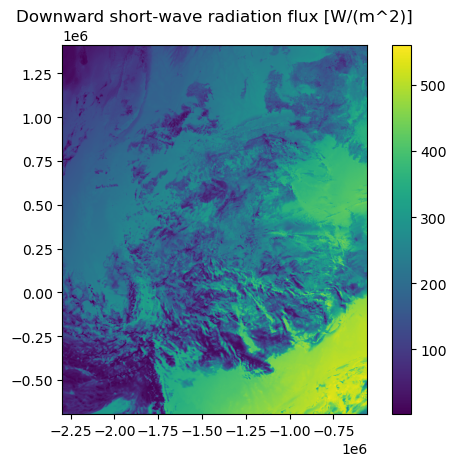

In [28]:
# plot HRRR COMBINED
bb = 10
dsw = hrdir.GetRasterBand(bb).ReadAsArray()

# Get the geotransform information
geotransform = hrdir.GetGeoTransform()

# Plot the data
plt.figure()
plt.imshow(dsw, cmap='viridis', extent=[geotransform[0], geotransform[0] + geotransform[1] * hrdir.RasterXSize,
                                      geotransform[3] + geotransform[5] * hrdir.RasterYSize, geotransform[3]])

plt.title(hrdir.GetRasterBand(bb).GetMetadata()['GRIB_COMMENT'])
plt.colorbar() 
plt.show()

In [29]:
spatial_info.GetAuthorityName(None)
spatial_info.GetAuthorityCode(None)

In [30]:
import random

def gdal_output_bounds(topo):
        geo_transform = topo.GetGeoTransform()
        return [
            geo_transform[0],
            geo_transform[3] + geo_transform[5] * topo.RasterYSize,
            geo_transform[0] + geo_transform[1] * topo.RasterXSize,
            geo_transform[3]
        ]


# Open the topo file (netCDF in your case)
topo = gdal.Open(ERW_TOPO_FILE, gdal.GA_ReadOnly)

# Open the first subdataset of topo file
topo1 = gdal.Open(topo.GetSubDatasets()[0][0])

# Create a spatial reference object
spatial_info = osr.SpatialReference()

# Set the spatial reference from the dataset's projection
spatial_info.ImportFromWkt(topo1.GetProjection())

# Now, you can get the EPSG code from the spatial reference
epsg_code = spatial_info.GetAuthorityName(None) + ":" + spatial_info.GetAuthorityCode(None)

# Print the EPSG code
print(f"EPSG Code: {epsg_code}")

# Define a temporary file for the warped output
mem_hrrr_file = '/vsimem/grib_%i.tif' % random.getrandbits(32)

# Create warp options
options = gdal.WarpOptions(
    dstSRS=epsg_code,  # Use the EPSG code
    outputBoundsSRS=epsg_code,  # Set output bounds in the same SRS
    outputBounds=gdal_output_bounds(topo1),  # Replace with actual bounds
    xRes=topo1.GetGeoTransform()[1],  # Set pixel resolution in X
    yRes=topo1.GetGeoTransform()[1],  # Set pixel resolution in Y
    multithread=True  # Enable multithreading for performance
)

# Perform the warp (reprojection) of the raster data
gdal.Warp(mem_hrrr_file, topo1, options=options)

# Open the warped file
hrrr_warp = gdal.Open(mem_hrrr_file, gdal.GA_ReadOnly)

# Verify the result
print(hrrr_warp.GetProjection())


EPSG Code: EPSG:32613
PROJCS["WGS 84 / UTM zone 13N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32613"]]


In [31]:
gdal.WarpOptions()

(<osgeo.gdal.GDALWarpAppOptions; proxy of <Swig Object of type 'GDALWarpAppOptions *' at 0x7fc1ecaa8f00> >,
 None,
 None)

In [32]:
epsg_code = spatial_info.GetAuthorityName(None) + ":" + spatial_info.GetAuthorityCode(None)

# temp file
mem_hrrr_file = '/vsimem/grib_%i.tif' % random.getrandbits(32)

# warp options for topo files
options = gdal.WarpOptions(
            dstSRS=epsg_code,
            outputBoundsSRS=epsg_code,
            outputBounds= gdal_output_bounds(topo1),
            xRes=topo1.GetGeoTransform()[1],
            yRes=topo1.GetGeoTransform()[1],
            multithread=True,
            resampleAlg= "cubic" # "bilinear"
        )

# warp file, original, options=topo1
gdal.Warp(mem_hrrr_file, hrrr_file, options=options)

## 3.5 reopen (save)
hrrr_warp = gdal.Open(mem_hrrr_file, gdal.GA_ReadOnly)

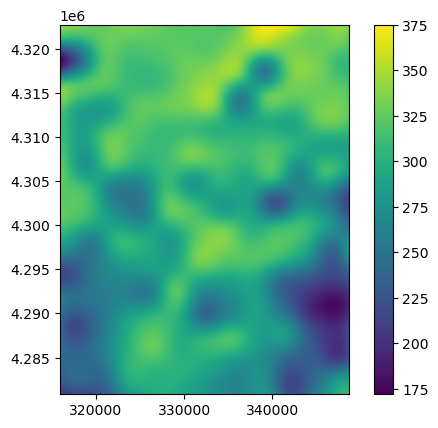

In [33]:
# Plot warped HRRR
band_hrrr = hrrr_warp.GetRasterBand(10) # 10th variable is sw
data_hrrr = band_hrrr.ReadAsArray()

# Get the geotransform information
geotransform = hrrr_warp.GetGeoTransform()

# Plot the data
plt.figure()
plt.imshow(data_hrrr, cmap='viridis', extent=[geotransform[0], geotransform[0] + geotransform[1] * hrrr_warp.RasterXSize,
                                      geotransform[3] + geotransform[5] * hrrr_warp.RasterYSize, geotransform[3]])
plt.colorbar()
plt.show()

In [34]:


def calculate_insolation(dem, zenith, hour, dlxy, latitude=38.8697, longitude=-106.9878, 
                         timezone=-7, visibility=60, RH=55, tempK=275.0, O3=0.02, alphag=0.2):
    """
    Calculate direct and diffuse insolation for a given hour and zenith angle based on DEM and other parameters.
    
    Parameters:
    - dem: DEM grid (2D array) representing elevation data
    - zenith: Array of zenith angles (1D)
    - hour: Hour of the day (integer)
    - dlxy: Grid resolution in meters (default=50)
    - latitude: Latitude for the location (default=38.8697)
    - longitude: Longitude for the location (default=-106.9878)
    - timezone: Timezone for the location (default=-7)
    - visibility: Visibility in km (default=60)
    - RH: Relative humidity in percentage (default=55)
    - tempK: Air temperature in Kelvin (default=275.0)
    - O3: Ozone thickness in meters (default=0.02)
    - alphag: Albedo of surrounding terrain (default=0.2)

    Returns:
    - Idir_hour: Direct insolation array (2D)
    - Idiff_hour: Diffuse insolation array (2D)
    """
    # Step 1: Generate Julian Day for March 1, 2023 (1 to 24 hours)
    jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

    # Step 2: Calculate Sun Position (Azimuth and Zenith) over the day
    sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
    azimuth, zenith_arr = insolf.sunpos(sunv)

    # Calculate normal vectors for shading (sv)
    sv = insolf.normalvector(zenith_arr, azimuth)

    # Use the zenith for the specified hour
    current_zenith = zenith[hour]

    # Step 3: Calculate shading effect
    sh = insolf.doshade(np.array(dem), dlxy, sv[:, hour])  # Use sv[:, hour] for correct index
    
    # Step 4: Calculate the insolation for this hour
    Idir_hour, Idiff_hour = insolf.insolation(current_zenith, jdrng[hour], dem, visibility, RH, tempK, O3, alphag)
    
    # Step 5: Apply hill shading
    hsh = insolf.hillshading(dem, dlxy, sunv[:, hour])  # Correct access to sunv for each hour
    
    # Step 6: Compute total insolation with shading (assuming Idiff_hour is not shaded)
    Idir = (Idir_hour * sh * hsh)
    Idif = (Idiff_hour * m.cos(current_zenith) * vf)
    I_tot = Idir + Idif  # Diffuse insolation is not shaded

    # Return the arrays
    return Idir, Idif, I_tot


In [35]:
zenith[9]
Idiff_hour

57.385275083702474

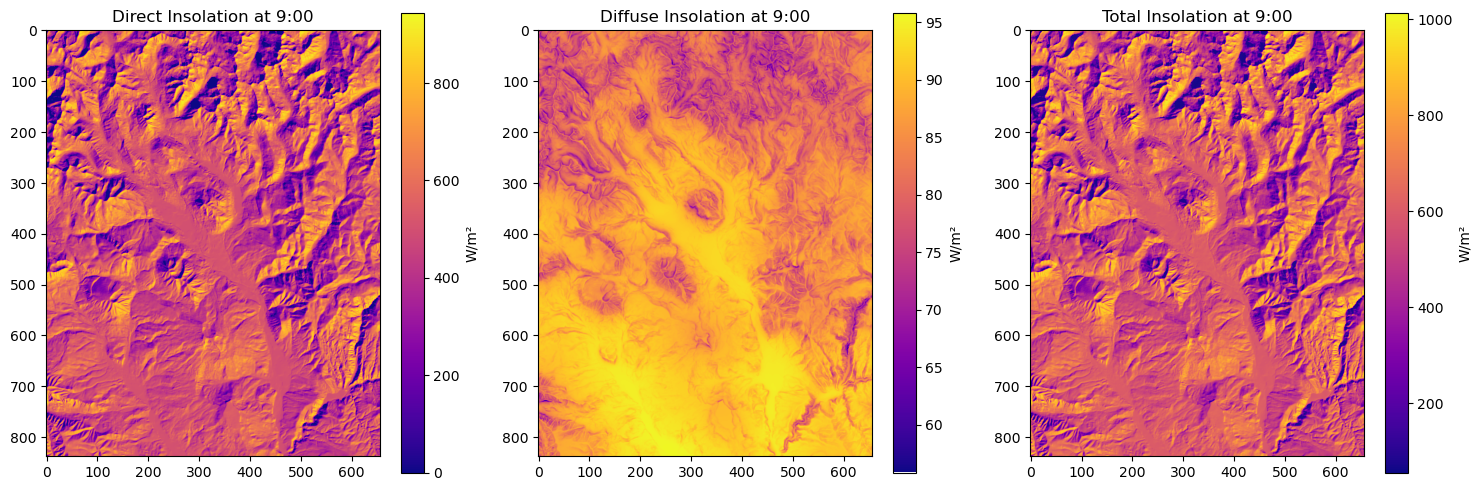

In [36]:
# Assuming you already have the DEM (d) and zenith array (zenith)
hour = 9  # Example: 9 AM
# zenith = ...  # Your zenith angles array (should be of size 24)
# dem = d  # Your DEM array

Idir_hour, Idiff_hour, I_tot = calculate_insolation(dem2, zenith, hour, x_resolution)

# Plotting the results for 9 AM (or any other hour you want)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(Idir_hour, cmap='plasma')
ax[0].set_title(f"Direct Insolation at {hour}:00")
fig.colorbar(ax[0].imshow(Idir_hour, cmap='plasma'), ax=ax[0], label="W/m²")

ax[1].imshow(Idiff_hour, cmap='plasma')
ax[1].set_title(f"Diffuse Insolation at {hour}:00")
fig.colorbar(ax[1].imshow(Idiff_hour, cmap='plasma'), ax=ax[1], label="W/m²")

ax[2].imshow(I_tot, cmap='plasma')
ax[2].set_title(f"Total Insolation at {hour}:00")
fig.colorbar(ax[2].imshow(I_tot, cmap='plasma'), ax=ax[2], label="W/m²")

plt.tight_layout()
plt.show()


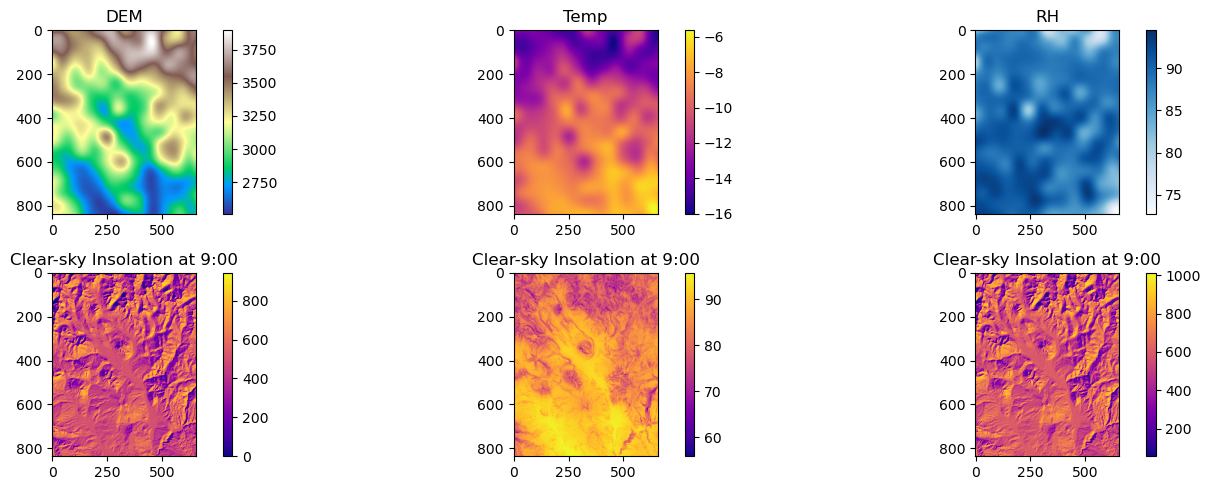

In [37]:
# simple vars
gpm = hrrr_warp.GetRasterBand(1).ReadAsArray() # Elelvation
temp = hrrr_warp.GetRasterBand(2).ReadAsArray() # Temperature C
rh = hrrr_warp.GetRasterBand(3).ReadAsArray() # RH %
dsw = hrrr_warp.GetRasterBand(10).ReadAsArray() #



# Plot raster data and store the returned image object
fig, axs = plt.subplots(2, 3, figsize=(15, 5))

# Inputs

im1 = axs[0, 0].imshow(gpm, cmap='terrain')  # elevation
axs[0, 0].set_title('DEM')
im2 = axs[0, 1].imshow(temp, cmap='plasma')  # temperature
axs[0, 1].set_title('Temp')
im3 = axs[0, 2].imshow(rh, cmap='Blues')  # relative humidity
axs[0, 2].set_title('RH')


# CALCULATE
Idir_hour, Idiff_hour, I_tot = calculate_insolation(dem2, zenith, hour, x_resolution)


im4 = axs[1, 0].imshow(Idir_hour, cmap='plasma')
axs[1, 0].set_title(f"Clear-sky Insolation at {hour}:00")
# fig.colorbar(ax[0].imshow(Idir_hour, cmap='plasma'), ax=ax[0], label="W/m²")

im5 = axs[1, 1].imshow(Idiff_hour, cmap='plasma')
axs[1, 1].set_title(f"Clear-sky Insolation at {hour}:00")
# fig.colorbar(ax[1].imshow(Idiff_hour, cmap='plasma'), ax=ax[1], label="W/m²")

im6 = axs[1, 2].imshow(I_tot, cmap='plasma')
axs[1, 2].set_title(f"Clear-sky Insolation at {hour}:00")
# fig.colorbar(ax[2].imshow(I_tot, cmap='plasma'), ax=ax[2], label="W/m²")

# Add colorbars
fig.colorbar(im1, ax=axs[0, 0]) 
fig.colorbar(im2, ax=axs[0, 1]) 
fig.colorbar(im3, ax=axs[0, 2]) 
fig.colorbar(im4, ax=axs[1, 0]) 
fig.colorbar(im5, ax=axs[1, 1]) 
fig.colorbar(im6, ax=axs[1, 2]) 

plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()

In [38]:


def calculate_insolation2(dem, zenith, hour, dlxy, latitude=38.8697, longitude=-106.9878, 
                         timezone=-7, visibility=60, RH=55, tempK=275.0, O3=0.02, alphag=0.2):
    """
    Calculate direct and diffuse insolation (GLOBAL HORIZONTAL)
    """
    # Step 1: Generate Julian Day for March 1, 2023 (1 to 24 hours)
    jdrng = insolf.julian_day(2023, 3, 1, np.arange(1, 25))

    # Step 2: Calculate Sun Position (Azimuth and Zenith) over the day
    sunv = insolf.sunvector(jdrng, latitude, longitude, timezone)
    azimuth, zenith_arr = insolf.sunpos(sunv)

    # Calculate normal vectors for shading (sv)
    sv = insolf.normalvector(zenith_arr, azimuth)

    # Use the zenith for the specified hour
    current_zenith = zenith[hour]

    # Step 3: Calculate shading effect
    sh = insolf.doshade(np.array(dem), dlxy, sv[:, hour])  # Use sv[:, hour] for correct index
    
    # Step 4: Calculate the insolation for this hour
    Idir_hour, Idiff_hour = insolf.insolation(current_zenith, jdrng[hour], dem, visibility, RH, tempK, O3, alphag)
    
    # Step 5: Apply hill shading
    hsh = insolf.hillshading(dem, dlxy, sunv[:, hour])  # Correct access to sunv for each hour
    
    # Step 6: Compute total insolation with shading (assuming Idiff_hour is not shaded)
    Idir = (Idir_hour * sh * hsh)
    Idif = (Idiff_hour * m.cos(current_zenith) * vf)
    I_tot = Idir + Idif  # Diffuse insolation is not shaded

    # Return the arrays
    return Idir_hour, Idif_hour, I_tot


In [39]:
np.full_like(dsw, 111)
Idir_hour

array([[  0.        ,   0.        ,   0.        , ..., 508.99362103,
        559.08270564, 559.13764089],
       [  0.        ,   0.        ,   0.        , ..., 508.87862559,
        558.95590194, 559.02004276],
       [  0.        ,   0.        ,   0.        , ..., 530.79317454,
        571.39375636, 571.47334189],
       ...,
       [806.21179406, 743.98845049, 672.79811233, ..., 303.31353212,
        371.02377901, 371.18172243],
       [648.60123477, 466.27990639, 271.07723744, ..., 377.47977583,
        472.42431766, 472.60064552],
       [264.43425203,  87.97466469,  83.62179356, ..., 473.10947798,
        508.57653561, 508.81820874]])

In [40]:

def clearness(IG, zenith, I0=1367): # Kt - clearness
    kt = IG / (I0 * math.cos(math.radians(zenith)) )
    return(kt)
               
def airmass(zenith): # m - airmass
    m = 1/math.cos(math.radians(zenith))
    return(m)

def localG2(kt, m):
    a0= 0.956; a1= 1.268; a2= 3.202; a3= -6.712; a4= 2.228; a5= -0.213; a6= 0.021; 
    solve1 = (a2 + (a3*kt) + (a4*kt*kt) + (a5*m) + (a6*m*m) )
    k = a0 - a1 * np.exp( -np.exp( solve1 ))
    return(k)


def diffusef_Lk2_boulder(IG, zenith_hr, I0=1367, m_elv = None):
    # clearness, airmass, and diffuse fraction (k)
    kt = clearness(IG, zenith_hr, I0)
    # airmass
    try: 
        m = elevational_airmass(zenith_hr, m_elv)
    except:
        m = airmass(zenith_hr)
    # diffuse fraction
    k0 = localG2(kt, m) 
    return(k0)

def elevational_airmass(zenith, elevation):
    """
    Calculate elevation-adjusted optical air mass
    Based on Young 1987
    Uses barometric formula for pressure
    """
    # Standard air mass calculation
    base_m = 1 / math.cos(math.radians(zenith))
    
    # Elevation adjustment
    # Approximate atmospheric pressure ratio at elevation
    # Uses standard atmospheric pressure model
    # pressure_ratio = math.pow(1 - (2.25577e-5 * elevation), 5.2559)
    pressure_ratio = np.power(1 - (2.25577e-5 * elevation), 5.2559)
    
    # Adjusted air mass
    adjusted_m = base_m * pressure_ratio
    
    return adjusted_m

In [41]:
import pandas as pd

def gridded_data_to_dataframe(sza, eth, ghi, ghics, difcs):
    """
    Convert gridded data into a Pandas DataFrame.

    Parameters:
    - sza: 2D array of solar zenith angles (shape: (nrows, ncols))
    - eth: 2D array of extraterrestrial solar irradiance (shape: (nrows, ncols))
    - ghi: 2D array of global horizontal irradiance (shape: (nrows, ncols))
    - ghics: 2D array of clear-sky global horizontal irradiance (shape: (nrows, ncols))
    - difcs: 2D array of clear-sky diffuse irradiance (shape: (nrows, ncols))
    - time_series: Array of timestamps for the time series (shape: (nrows * ncols,))

    Returns:
    - Pandas DataFrame with the time series as index and the variables as columns
    """
    # Flatten the 2D arrays into 1D arrays
    sza_flat = sza.flatten()
    eth_flat = eth.flatten()
    ghi_flat = ghi.flatten()
    ghics_flat = ghics.flatten()
    difcs_flat = difcs.flatten()

    # Create a DataFrame
    df = pd.DataFrame({
        'sza': sza_flat,
        'eth': eth_flat,
        'ghi': ghi_flat,
        'ghics': ghics_flat,
        'difcs': difcs_flat
    })

    # Add the time series as the index
    # df['timestamp'] = time_series
    # df.set_index('timestamp', inplace=True)

    return df


In [42]:
sza = np.full_like(dsw, zenith[hour])
eth = np.full_like(dsw, 1367)
ghi = dsw/m.cos(zenith[hour]) # shape = (837, 656)
ghics = Idir_hour
difcs = Idiff_hour

# time_series = pd.date_range(periods=sza.size, freq='T')

# Convert the gridded data into a Pandas DataFrame
df = gridded_data_to_dataframe(sza, eth, ghi, ghics, difcs)

# Display the first few rows of the DataFrame
print(df.head())


from gisplit import GISPLIT
gs = GISPLIT(engine="reg", climate=None)
pred = gs.predict(df)

pred

         sza     eth         ghi  ghics      difcs
0  56.743246  1367.0  354.228677    0.0  78.896386
1  56.743246  1367.0  353.920661    0.0  78.281956
2  56.743246  1367.0  353.603522    0.0  75.646462
3  56.743246  1367.0  353.278051    0.0  72.656306
4  56.743246  1367.0  352.945048    0.0  68.298727


/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/earthsky/lib/python3.11/site-packages/gisplit/gisplit.py:291: UserWarning: expected 1min time step. Got 0 days 00:00:01
  warnings.warn(message, UserWarning)


ValueError: window must be an integer 0 or greater

In [ ]:
## HRRR

# simple vars
gpm = hrrr_warp.GetRasterBand(1).ReadAsArray() # Elelvation
temp = hrrr_warp.GetRasterBand(2).ReadAsArray() # Temperature C
rh = hrrr_warp.GetRasterBand(3).ReadAsArray() # RH %
dsw = hrrr_warp.GetRasterBand(10).ReadAsArray() #



# Plot raster data and store the returned image object
fig, axs = plt.subplots(2, 3, figsize=(15, 5))

# Inputs
# Downscale HRRR
# CALCULATE CLEARSKY w/ rh and temp
Idir_hour, Idiff_hour, I_tot = calculate_insolation2(dem2, zenith, hour, x_resolution, RH=rh.astype(np.double),
                                                   tempK= (temp.astype(np.double) + 273.15) )




## for GISPLIT
# sza: the solar zenith angle, in degrees
# eth: the extraterrestrial solar irradiance, in W/m2
# ghi: the global horizontal irradiance, in W/m2
# ghics: the clear-sky global horizontal irradiance, in W/m2
# difcs: the clear-sky diffuse irradiance, in W/m2
sza = np.full_like(dsw, zenith[hour])
eth = np.full_like(dsw, 1367)
ghi = dsw/m.cos(zenith[hour]) # shape = (837, 656)
ghics = Idir_hour
difcs = Idiff_hour

df = gridded_data_to_dataframe(sza, eth, ghi, ghics, difcs)

# GISPLIT  *****
k = 0.2

# split
hrrr_dir = ghi * (1-k)
hrrr_dif = ghi * k

# resample


# downsample
hrrr_dif = hrrr_dir_cubic * vf * zen_hr
hrrr_dir = hrrr_dif_cubic * sh * hsh

im1 = axs[0, 0].imshow(gpm, cmap='terrain')  # elevation
axs[0, 0].set_title('DEM')
im2 = axs[0, 1].imshow(temp, cmap='plasma')  # temperature
axs[0, 1].set_title('Temp')
im3 = axs[0, 2].imshow(rh, cmap='Blues')  # relative humidity
axs[0, 2].set_title('RH')


im4 = axs[1, 0].imshow(Idir_hour, cmap='plasma')
axs[1, 0].set_title(f"Clear-sky Insolation at {hour}:00")

im5 = axs[1, 1].imshow(Idiff_hour, cmap='plasma')
axs[1, 1].set_title(f"Clear-sky Insolation at {hour}:00")

im6 = axs[1, 2].imshow(I_tot, cmap='plasma')
axs[1, 2].set_title(f"Clear-sky Insolation at {hour}:00")




# Add colorbars
fig.colorbar(im1, ax=axs[0, 0]) 
fig.colorbar(im2, ax=axs[0, 1]) 
fig.colorbar(im3, ax=axs[0, 2]) 
fig.colorbar(im4, ax=axs[1, 0]) 
fig.colorbar(im5, ax=axs[1, 1]) 
fig.colorbar(im6, ax=axs[1, 2]) 

plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


In [ ]:
print(rh.astype(np.double).shape)
print(dem2.shape)

In [ ]:
import numpy as np
import pygrib
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from osgeo import osr, gdal

# Step 1: Load the DEM data using netCDF4
with Dataset(ERW_TOPO_FILE) as dem:
    d = dem['dem'][:]  # Read DEM data
    lat = dem['y'][:]  # Latitude from the DEM file
    lon = dem['x'][:]  # Longitude from the DEM file
    projection = dem['projection'][:]  # Projection string (WGS84/UTM Zone 13N)
    
    # Print projection details for reference
    print(f"Projection: {projection}")

# Step 2: Open the GRIB file to read elevation and downward shortwave radiation
time_utc = 19
hrrr_file = f"{HRRR_DATA}hrrr.20230301/hrrr.t{time_utc-6}z.wrfsfcf06.grib2"

# Open GRIB file using pygrib
grbs = pygrib.open(hrrr_file)

# Select the necessary layers (Geopotential height and Downward short-wave radiation flux)
elevation_grb = grbs.select(name="Orography")[0]
dswrf_grb = grbs.select(name="Downward short-wave radiation flux")[0]

# Read data from GRIB layers
elevation_data = elevation_grb.values  # Geopotential height data [gpm]
dswrf_data = dswrf_grb.values  # Downward shortwave radiation flux [W/m^2]

# Get latitude and longitude from GRIB metadata
lats, lons = elevation_grb.latlons()

# Step 3: Reproject the GRIB data (elevation and DSWRF) to the DEM's CRS (WGS84/UTM zone 13N)

# Step 3.1: Define the projection of the DEM (WGS84/UTM Zone 13N)
utm_proj = osr.SpatialReference()
utm_proj.ImportFromEPSG(32613)  # WGS84/UTM Zone 13N

# Step 3.2: Create the GDAL dataset for the DEM to use its spatial extent
dem_transform = from_origin(lon[0], lat[0], abs(lon[1] - lon[0]), abs(lat[0] - lat[1]))
dem_crs = 'EPSG:32613'  # Assuming UTM Zone 13N

# Step 4: Reproject the data using GDAL to match the DEM's spatial reference
# We will create a temporary memory raster to hold the reprojected data

def reproject_data_to_utm(src_data, src_lon, src_lat, target_crs, target_transform):
    # Create a memory raster for the output
    driver = gdal.GetDriverByName('MEM')
    src_ds = driver.Create('', src_data.shape[1], src_data.shape[0], 1, gdal.GDT_Float32)
    src_ds.GetRasterBand(1).WriteArray(src_data)
    
    # Set source projection and geotransform
    src_ds.SetProjection('EPSG:4326')  # Assuming source is in WGS84 (EPSG:4326)
    src_ds.SetGeoTransform(from_origin(src_lon[0], src_lat[0], abs(src_lon[1] - src_lon[0]), abs(src_lat[0] - src_lat[1])))

    # Create a destination memory raster
    dst_ds = driver.Create('', src_data.shape[1], src_data.shape[0], 1, gdal.GDT_Float32)
    
    # Set the destination projection and transform
    dst_ds.SetProjection(target_crs)
    dst_ds.SetGeoTransform(target_transform)
    
    # Reproject the data
    gdal.ReprojectImage(src_ds, dst_ds, 'EPSG:4326', target_crs, gdal.GRA_NearestNeighbour)
    
    # Get the reprojected data
    reprojected_data = dst_ds.GetRasterBand(1).ReadAsArray()
    return reprojected_data

# Step 5: Reproject both elevation and DSWRF data
elevation_reprojected = reproject_data_to_utm(elevation_data, lons, lats, 'EPSG:32613', dem_transform)
dswrf_reprojected = reproject_data_to_utm(dswrf_data, lons, lats, 'EPSG:32613', dem_transform)

# Step 6: Clip the reprojected data to match the DEM's bounding box (spatial extent)
# Clip by checking for valid ranges (masking NaN values or invalid areas)
valid_mask = np.isfinite(d)

elevation_reprojected = np.where(valid_mask, elevation_reprojected, np.nan)
dswrf_reprojected = np.where(valid_mask, dswrf_reprojected, np.nan)

# Step 7: Visualize the Reprojected Data (Optional)
# Plot elevation and downward shortwave radiation flux data with the DEM grid
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Plot reprojected Elevation data
cax1 = ax[0].imshow(elevation_reprojected, cmap='terrain', origin='upper')
ax[0].set_title("Reprojected Elevation (Geopotential Height)")
fig.colorbar(cax1, ax=ax[0], label="Height (gpm)")

# Plot reprojected DSWRF data
cax2 = ax[1].imshow(dswrf_reprojected, cmap='plasma', origin='upper')
ax[1].set_title("Reprojected Downward Shortwave Radiation Flux")
fig.colorbar(cax2, ax=ax[1], label="W/m^2")

plt.tight_layout()
plt.show()


In [ ]:
jd <-  JD(dtime)

# timezone
zchng = dtime; attr(zchng, "tzone") <- "US/Mountain"
tmz = as.numeric(format(zchng, "%H")) - as.numeric(format(dtime, "%H"))
  tmz = -6
  # sunvector
  sv <-  sunvector(jd,lat_lon[1],lat_lon[2],tmz) # -6 if after first sunday in march 
  sp1 <- sunpos(sv)
  # ADD CHECK FOR SUNDOWN VALUES ?
  # daylight hours (zenith <= 90)
  # sp <-  ifelse(sp1[2]>=90, 90, sp1[2]) # sp1[which(sp1[,2]<=90),] 
  # sv <- sv[which(sp1[,2]<=90),]
  # sv <- c(1,-0,-0)
  # specify
  zenith <<-  sp1[2]
  azim <-  sp1[1]
  azimuth_eq <-  azim -180
  # run shade
  d_mat <- as.matrix(dem)
  dl <-  res(dem)[1]
  sh <- doshade(d_mat, sv, dl=dl) 
  sh0 <<- make.raster(sh, dem) 
  # zenith and incident angles
  s_a <- slope.aspect(dem)
  cos_inc <<- cos.slope(zenith, azimuth_eq, aspect = s_a[[2]], slope = s_a[[1]])
  # insolation at hour
  if(!exists('visibility')){insol.params()}
  height <- array(dem)
  Idirdif <-  insolation(zenith,jd,height,visibility,RH,tempK,O3,alphag)
  Ib <-  matrix(Idirdif[,1],nrow=nrow(dem),ncol=ncol(dem), byrow = T)
  Id <-  matrix(Idirdif[,2],nrow=nrow(dem),ncol=ncol(dem), byrow=T)
  # layers
  Ib0 <<- make.raster(Ib, dem)
  Id0 <<- make.raster(Id, dem) 
  #
  # final output - TOPOGRAPHIC SOLAR MODELS
  sw0 <<- Ib0 + Id0 * cos(radians(zenith))# Dh
  sw1 <<- Ib0 * cos_inc * sh0 # direct beam component
  sw2 <<- Id0 * cos(radians(zenith)) * viewf # diffuse component
  sw3 <<- sw1 + sw2 # direct and diffuse
  sw3_z <<- (Ib0 * cos(radians(zenith)) * sh0) + (Id0 * cos(radians(zenith)) * viewf)
